In [28]:
import pandas as pd # for data manipulation
import numpy as np # for data manipulation
import matplotlib.pyplot as plt # for data plotting
import scipy.optimize as opt 
from scipy.optimize import minimize

### Exercise 02 - Model for Poisson Regression
**Jenny Laberg Nilsson**  
**BERN02 - 2026/09**

**Project:** Make a model for Poisson regression and estimate the parameters using Maximum Likelihood. Generate 3 datasets of data sampled from your Poisson distribution. Save the results to a CSV file.   
**Model:** Poisson regression

In [29]:
# load bird count data
bird_df = pd.read_csv("../data/bird_count.csv")
# sort years before plotting
bird_df_sorted = bird_df.sort_values(by='yr')
# extract values into NumPy arrays
x = bird_df_sorted['yr'].values
y = bird_df_sorted['count'].values
# center the year so that 1999 becomes the baseline (instead of year 0)
x_centered = x - x.min()

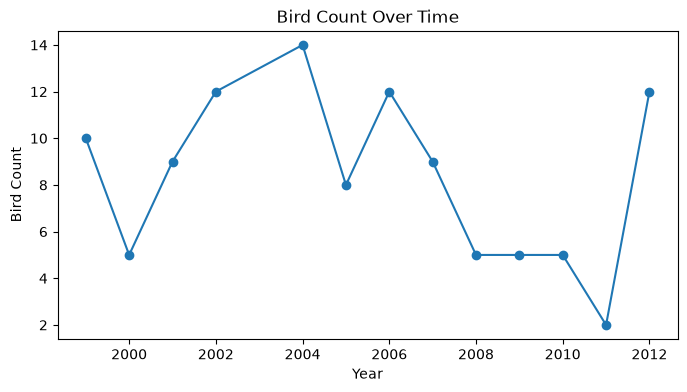

In [30]:
# plot the data without any adjustments for initial overview
plt.figure(figsize=(8, 4))
plt.title("Bird Count Over Time")
plt.plot(x, y, marker='o')
plt.xlabel("Year")
plt.ylabel("Bird Count")
plt.show()

In [31]:
# function for poisson regression
def predict_lambda(beta, x):
    """
    Find the estimated rate (lambda) by computing: 
    lambda = e^(X_i^T*Beta) 
    """
    beta_0 = beta[0]
    beta_1 = beta[1]
    return(np.exp(beta_0 + beta_1 * x))

In [32]:
def maximum_likelihood_estimation(beta, x, y):
    """
    Computes log-likelihood for Poisson regression.
    """
    # get the lambda (estimated rate) by calling the function
    lambda_i = predict_lambda(beta, x)

    # compute the Log-Likelihood function 
    log_likelihood = np.sum(y * np.log(lambda_i) - lambda_i)
    # return negative log-likelihood since scipy.optimize.minimize performs minimization
    return -log_likelihood

In [33]:
def optimize_parameters(beta, x, y):
    # use built in function for optimizing of parameters using scipy.optimize.minimize
    fit_result = opt.minimize(maximum_likelihood_estimation, beta, args=(x, y))

    # extract optimal parameters
    beta_hat = fit_result.x
    return(beta_hat)

In [34]:
# set initial guess for [beta_0, beta_1] to (0,0)
initial_beta = [0.0, 0.0]
# run the built in optimizer to find the beta parameters!
beta_hat = optimize_parameters(initial_beta, x_centered, y)
print(beta_hat)

[ 2.32533195 -0.03244318]


In [35]:
### Now generate three samples of data (hypothetical observations)
# predict lambda (rate function) using my estimated beta values
lambda_hat = predict_lambda(beta_hat, x_centered)
# make a list to put the generated datasets
made_samples = []

for sample_id in range(0, 3):
    # generate hypothetical bird counts from the fitted Poisson distributions using the predicted rate function (lambda)
    simulated_counts = np.random.poisson(lam=lambda_hat)
    
    # store in a temporary DataFrame with a column indicating the sample ID
    sample_df = pd.DataFrame({
        'sample_id': sample_id, # index nr.
        'yr': x,  # years 
        'simulated_count': simulated_counts # simulated bird count
    })
    made_samples.append(sample_df)

# combine all 3 samples into a single DataFrame
all_samples_df = pd.concat(made_samples)
# save to a CSV file for submission
all_samples_df.to_csv('../results/assignment_2.csv', index = 'False')
# preview file
print(all_samples_df)

    sample_id    yr  simulated_count
0           0  1999                9
1           0  2000                9
2           0  2001                4
3           0  2002                7
4           0  2004                6
5           0  2005                7
6           0  2006               12
7           0  2007                5
8           0  2008                3
9           0  2009               10
10          0  2010               14
11          0  2011                3
12          0  2012               11
0           1  1999               10
1           1  2000               13
2           1  2001                6
3           1  2002                8
4           1  2004                7
5           1  2005               12
6           1  2006               11
7           1  2007                4
8           1  2008                5
9           1  2009                7
10          1  2010               11
11          1  2011                7
12          1  2012                5
0

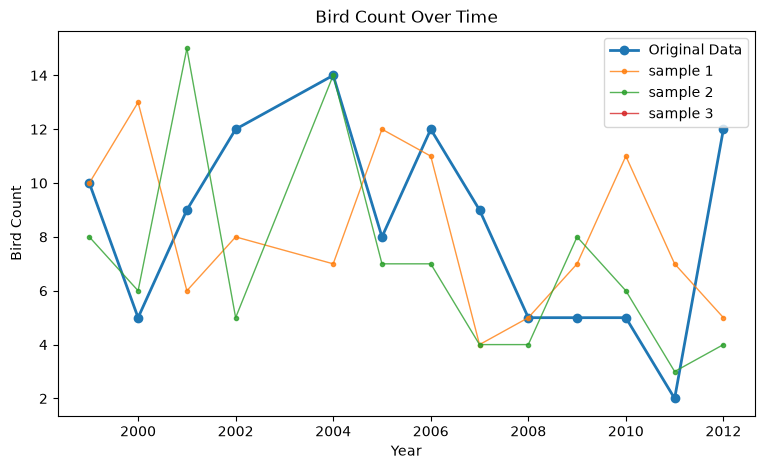

In [36]:
# plot the raw data
plt.figure(figsize=(9, 5))
plt.plot(x, y, marker='o',linewidth = 2, label = 'Original Data')
# plot the newly generated data on top of the old data
for sample_num in [1,2,3]:
    sample_data = all_samples_df[all_samples_df['sample_id'] == sample_num]
    plt.plot(sample_data['yr'], sample_data['simulated_count'], marker='.', linewidth = 1, alpha = 0.8, label = f'sample {sample_num}')
plt.title("Bird Count Over Time")
plt.xlabel("Year")
plt.ylabel("Bird Count")
plt.legend()
plt.show()